<a href="https://colab.research.google.com/github/JungYeoni/tobigs-25th/blob/%EA%B3%BC%EC%A0%9C_%EC%A0%9C%EC%B6%9C/Week5/XAI/%EC%9D%B4%EC%A0%95%EC%97%B0/5%EC%A3%BC%EC%B0%A8_XAI_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ToBigs 정규세션 5주차 XAI 과제


# 1. Lime

In [1]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=3e05167915c2fb9e7327a32aca29dcb2f08277b495e84e388c997919c09bbc33
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


### LIME (Local Interpretable Model-agnostic Explanations) 실습
LIME은 모델의 종류와 상관없이(Model-agnostic) 특정 데이터 포인트의 예측 결과를 국소적으로(Local) 설명하는 기법입니다.

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime import lime_tabular

# 1. 데이터 로드 (유방암 데이터셋) -> 이진분류 데이터셋
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [3]:
# features
print(X.info())
print(y.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [4]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 분류 모델 생성 및 학습 (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


# LIME Explainer 초기화
explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train), # LIME 은 학습 데이터 분포를 기준으로 가짜 샘플을 만들기 때문에, 훈련 데이터 전체의 형태를 알아야한다.
    feature_names=data.feature_names, # 각 열이 무엇을 의미하는지 알려줌
    class_names=data.target_names, # 예측 클래스 이름 (숫자 대신 실제 클래스 이름으로 보여주기 위해 사용)
    mode='classification' # 해당 문제는 유방암이다/아니다를 찾는 분류 문제. -> LIME이 분류 방식으로 설명하게 설정
)

# 특정 데이터 샘플에 대해 설명 생성
# 테스트 셋의 첫 번째 데이터를 대상으로 설명 -> local explanation

i = 0 # 설명할 샘플 선택
exp = explainer.explain_instance(
    data_row=X_test.iloc[i], # 설명할 대상 1개 -> test 데이터의 i번째 행
    predict_fn=rf_model.predict_proba, # LIME이 사용할 블랙박스 모델의 예측 함수
    num_features=5 # 설명 결과에 상위 5개 주요 feature만 보여줌 -> 모든 feature를 보여주면 해석이 어려워지기 때문
)

# 결과 시각화
print(f'실제 라벨: {data.target_names[y_test[i]]}')
print(f'모델의 예측 확률: {rf_model.predict_proba(X_test.iloc[[i]])}')

# 노트북 내에서 시각화 결과 출력
exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

실제 라벨: benign
모델의 예측 확률: [[0.03 0.97]]


[해석]

왼쪽: 예측 확률 (Prediction probabilities)
- `mailgnant`: 0.03
- `benign`: 0.97
-> 모델은 데이터가 악성보다는 정상일 가능성이 더 높다고 판단함.

오른쪽: 어떤 feature가 그 예측에 기여했는지
- 주황색 박스
  Feature -> 변수 이름
  Value -> 그 샘플의 실제 값

  이 데이터 포인트(환자)의 특징 값이 다음과 같음

- 주황색 = benign 쪽으로 밀어준 변수 -> 어떤 feature가 예측에 영향을 줬는지 (설명을 보여줌)

Q1. LIME의 핵심 동작 과정에 대해서 서술해주세요.

답:
1. 원본 데이터를 조금씩 바꾼 perturbation 샘플을 많이 만든다.

    이미지의 경우에는 일부 영역을 가리거나, 빼서 여러 버전을 만들 수 있다. 텍스트의 경우에는 단어를 빼거나 포함 여부를 바꾸는 등의 방식을 사용하고, 표 데이터 같은 경우에는 특정 feature 값을 바꿔서 비슷한 샘플을 만들 수 있다.

2. 원본과의 거리 계산을 통해 가중치를 부여한다.

    위에서 만든 가짜 샘플이 원본과 얼마나 비슷한지를 계산하고, 원본에 가까울수록 큰 가중치를 부여한다.
    즉, 원본과 비슷한 샘플이 더 중요하고, 멀리 떨어진 샘플은 덜 중요하게 보는 것과 같다.
3. 블랙박스 모델의 예측값을 도출한다.

    가짜 샘플들을 원래 블랙박스 모델에 넣어 각 샘플에 대한 예측값을 얻는다.
4. 핵심 특징 선택 -> `num_featrues=5`

    Lasso를 사용하여 불필요한 노이즈를 날리고, 예측에 큰 영향을 준 Top K 의 특징만 남긴다.
    
    이 과정은 코드에서는 보이지 않지만 `explain_instance()` 내부에서 자동으로 수행된다.

5. 선형 모델 학습
    - 입력: 가짜 샘플의 특징 정보
    - 출력: 블랙박스 모델의 예측값
    - 가중치: 원본과의 유사도
    
    핵심 특징과 가중치로 선형 방정식을 그어 각 특징의 기여도 개수를 도출한다. 선형 모델의 계수를 보면 어떤 feature가 예측을 올렸는지, 내렸는지를 알 수 있다. (계수의 절대값이 클수록 영향력이 크다.)

Q2. LIME model에서의 surrogate model의 역할을 설명해주세요.

답:LIME에서 surrogate model은 복잡한 블랙박스 모델의 예측을 직접 해석하기 어렵기 때문에, 특정 입력값 주변에서만 원래 모델을 단순한 해석 가능한 모델로 근사하는 역할을 한다. LIME은 원본 데이터 주변의 가짜 샘플들을 만들고, 이에 대한 블랙박스 모델의 예측값을 바탕으로 선형모델을 학습한다. 이 surrogate model을 통해 해당 입력에 대해 어떤 특징이 예측에 영향을 주었는지 설명할 수 있다. 즉, surrogate model은 블랙박스 모델의 국소적 의사결정을 해석 가능하게 바꿔주는 역할을 한다.

---

#2. SHAP

In [5]:
!pip install shap

### SHAP (SHapley Additive exPlanations)
SHAP은 게임 이론의 Shapley Value를 기반으로, 각 특성이 모델의 예측값에 얼마나 기여했는지를 수치화하여 설명하는 기법입니다.

--- 전체 데이터의 특성 중요도 (Summary Plot) ---


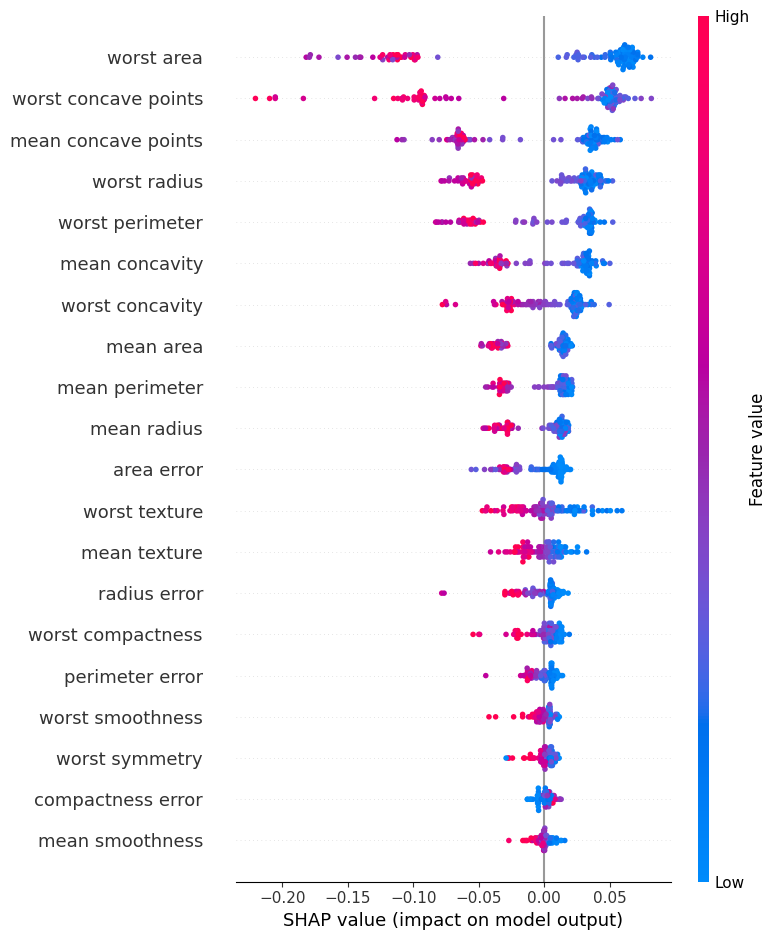

In [6]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# SHAP Explainer 초기화, ML 모델을 argument로
explainer_shap = shap.TreeExplainer(rf_model)

# SHAP Value 계산
shap_values = explainer_shap.shap_values(X_test)
'''
텍스트 데이터 전체에 대해 각 feature의 SHAP 계산 -> shape: (테스트 데이터 개수, 피처 개수)

shap_values[0][0] = 0.12

-> 첫 번째 데이터에서 첫 번째 피처가 예측을 +0.12만큼 올렸다.
'''


# 결과 시각화 준비
'''
이진분류이기 때문에 explainer_shap.shap_values()의 결과가 다음과 같은 리스트 형태거나,

shap_values = [
    class0 shap values,
    class1 shap values
]

'''

if isinstance(shap_values, list):

    '''

    '''

    target_shap_values = shap_values[1] # 엉성 클래스 기준 shap 확인하기
    base_value = explainer_shap.expected_value[1] # base_value는 데이터 평균 예측 확률
else:
    if len(shap_values.shape) == 3: # 출력 구조가 (n_samples, n_features, n_classes)
        target_shap_values = shap_values[:, :, 1]
        base_value = explainer_shap.expected_value[1]
    else:
        target_shap_values = shap_values
        base_value = explainer_shap.expected_value

# Summary plot -> feature importance
print("--- 전체 데이터의 특성 중요도 (Summary Plot) ---")
shap.summary_plot(target_shap_values, X_test)


--- 전체 데이터의 특성 중요도 (Summary Plot) ---


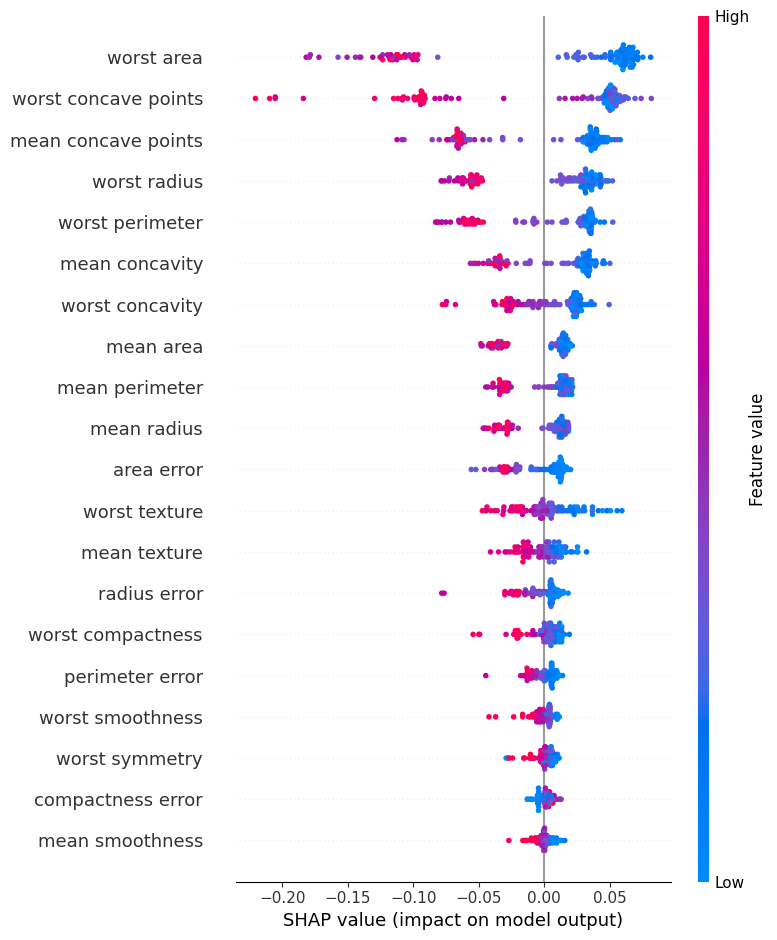

In [7]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# SHAP Explainer 초기화, ML 모델을 argument로
explainer_shap = shap.TreeExplainer(rf_model)

# SHAP Value 계산
shap_values = explainer_shap.shap_values(X_test)
'''
텍스트 데이터 전체에 대해 각 feature의 SHAP 계산 -> shape: (테스트 데이터 개수, 피처 개수)

shap_values[0][0] = 0.12

-> 첫 번째 데이터에서 첫 번째 피처가 예측을 +0.12만큼 올렸다.
'''


# 결과 시각화 준비
if isinstance(shap_values, list):

    '''
    출력결과가 다음과 같은 경우
    hap_values = [
      class0 shap values,
      class1 shap values
    ]
    '''

    target_shap_values = shap_values[1] # 엉성 클래스 기준 shap 확인하기
    base_value = explainer_shap.expected_value[1] # base_value는 데이터 평균 예측 확률
else:
    if len(shap_values.shape) == 3: # 출력 구조가 (n_samples, n_features, n_classes)
        target_shap_values = shap_values[:, :, 1]
        base_value = explainer_shap.expected_value[1]
    else:
        target_shap_values = shap_values
        base_value = explainer_shap.expected_value

# Summary plot -> feature importance
print("--- 전체 데이터의 특성 중요도 (Summary Plot) ---")
shap.summary_plot(target_shap_values, X_test)


Q3.  SHAP Value가 양수인 특성과 음수인 특성은 각각 예측 결과에 어떤 영향을 주는지 서술하세요.

답: SHAP Value가 양수인 특성은 모델이 예측값을 기준값보다 더 크게 만드는 방향으로 기여했음을 의미한다. 즉, 분류문제에서는 특정 클래스에 속할 확률이나 점수를 높이는 역할을 하고, 회귀문제에서는 예측값을 증가시키는 방향으로 작용한다.

반대로 SHAP Value가 음수인 특성은 해당 특성이 모델의 예측값을 기준값보다 더 낮추는 방향으로 기여했음을 의미한다. 분류 문제에서는 특정 클래스에 속할 확률이나 점수를 낮추고, 회귀문제에서는 예측값을 감소시키는 역할을 한다.

따라서 부호는 예측을 어느 방향으로 밀었는지를 나타내고, 절댓값 크기는 그 영향력의 정도를 나타낸다.


Q4. 기존 Tree 기반 ML Model(RF)에서 사용하는 entropy 혹은 geni index 기반 feature importance와 SHAP의 feature importance의 차이점을 서술하세요.

답: 트리기반 모델에서 사용하는 feature importance는 트리를 분할할 때 해당 특성이 불순도를 얼마나 많이 감소시켰는지를 전체 모댈 수준에서 누적하여 전체 모델에서 어떤 변수가 중요한지를 전반적으로 보는 값이고, SHAP의 feature importance는 각 feature가 특정 예측값에 얼마나, 그리고 어느 방향으로 기여했는지를 Shapley Value로 계산한 것이다.
즉, 어떤 feature가 예측값을 높였는지 또는 낮췄는지를 개별 데이터 단위에서 확인할 수 있고, 이를 여러 샘플에 대해 평균내면 전역적 중요도까지 해석할 수 있다.

---

# 3. Grad-CAM

### Grad-CAM (Gradient-weighted Class Activation Mapping)
Grad-CAM은 CNN 기반의 딥러닝 모델이 이미지의 어떤 영역을 보고 특정 클래스로 분류했는지를 중요도에 따라 히트맵(Heatmap) 형태로 시각화하는 기법입니다. 특성 맵(Feature Map)에 흐르는 그래디언트 정보를 사용하여 가중치를 계산합니다.

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 115MB/s]


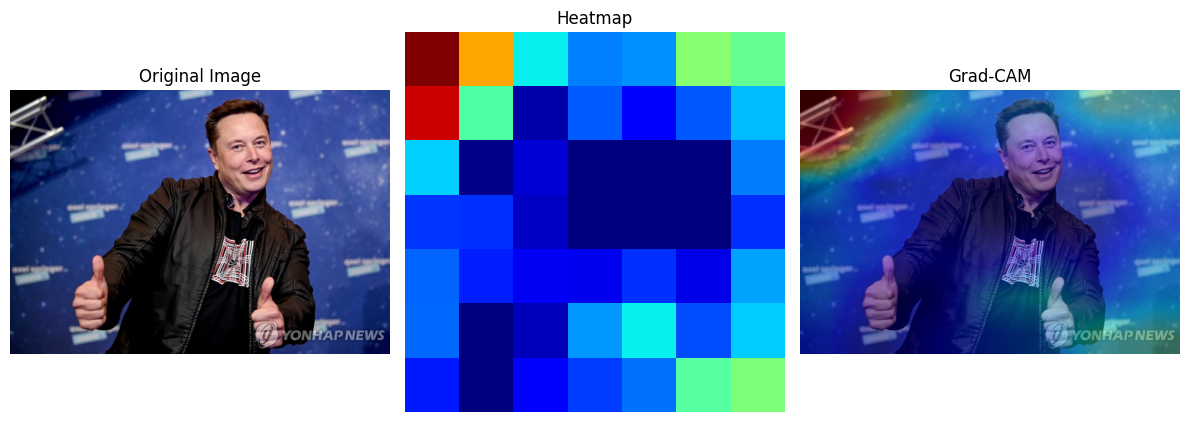

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import requests
from io import BytesIO

# 1. 사전 학습된 모델 로드 (VGG16)
# weights 매개변수를 사용하여 최신 방식으로 로드합니다.
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model.eval() # 평가 모드로 전환 -> dropout/batchnorm 같은 학습 레이어가 학습 모드처럼 동작하지 않게 함 (학습하려는게 아닌 학습된 모델로 예측 + 해석만하기 떄문)

# 그래디언트와 특성 맵을 저장할 변수
gradients = None # backward 때 해당 레이어를 기준으로 들어오는 gradient 저장
activations = None # foward 때 해당 레이어의 출력값 저장

# hook 함수 정의 - 매번 모델 구조를 직접 뜯어서 중간 값을 매번 꺼내기 번거롭기 때문에 사용
def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0] # backward 연산이 끝났을 때 해당 레이어의 출력(feature map)을 저장

def forward_hook(module, input, output): # forward 연산이 끝났을 때 해당 레이어의 출력 저장
    global activations
    activations = output

# 마지막 컨볼루션 층에 훅 등록 (VGG16의 경우 features의 30번 레이어)
target_layer = model.features[30]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# 2. 이미지 로드 및 전처리
url = 'https://img2.yna.co.kr/photo/etc/epa/2020/12/02/PEP20201202052601055_P4.jpg'
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB') # RGB 3채널로 변환

preprocess = transforms.Compose([
    transforms.Resize((224, 224)), # VGG는 보통 224x224 입력을 기대함.
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img).unsqueeze(0) # 배치 차원 추가 (3, 224, 224) -> (1, 3, 224, 224)

# 3. 모델 예측 및 Grad-CAM 계산
output = model(input_tensor)
pred_index = output.argmax(dim=1).item() # 클래스 중 점수가 가장 큰 클래스의 인덱스 선택

# 역전파 수행
model.zero_grad()
output[0, pred_index].backward() # 모델이 가장 높게 예측한 클래스 점수에 대해 backward

# 4. Grad-CAM 히트맵 생성
# 글로벌 평균 풀링 (GAP)을 통한 가중치 미분값 계산
weights = torch.mean(gradients, dim=(2, 3), keepdim=True) # 공간축인 height, width 방향으로 평균

# 특성 맵과 가중치 결합
# heatmap 생성
heatmap = torch.sum(weights * activations, dim=1).squeeze() # 각 feature map에 weight를 곱해서 모든 채널을 더해서 하나의 2D heatmap으로 만드는 과정
heatmap = F.relu(heatmap) # ReLU 적용 (양의 영향만 고려)

# 0~1 사이 정규화
if torch.max(heatmap) != 0:
    heatmap /= torch.max(heatmap)
heatmap = heatmap.detach().cpu().numpy()

# 5. 결과 시각화
img_cv = np.array(img)
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)

# 히트맵 리사이즈 및 컬러맵 적용
heatmap_resized = cv2.resize(heatmap, (img_cv.shape[1], img_cv.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# 원본이미지와 히트맵 합성 (Bayer 변환 고려)
superimposed_img = cv2.addWeighted(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB), 0.6, cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB), 0.4, 0)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Heatmap')
plt.imshow(heatmap, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Grad-CAM')
plt.imshow(superimposed_img)
plt.axis('off')

plt.tight_layout()
plt.show()

Q5. Grad-CAM에서 마지막 컨볼루션 층(Last Conv Layer)의 정보를 사용하는 이유는 무엇인가요?

답:마지막 컨볼루션 층은 위치 정보와 고수준 의미 정보를 가장 잘 보존하는 층이다. 따라서 마지막 컨볼루션 층의  feature map을 이용해야 모델이 어떤 영역을 근거로 판단했는지 히트맵으로 시각화할 수 있다.

Q6. Grad-CAM 결과에서 붉게 표시되는 영역(High Activation)은 모델 판단에 어떤 의미를 갖는지 서술하세요.

답: 목표 클래스에 대한 gradient와 feature map을 이용해 계산했을 때 값이 크게 나온 위치로, 즉 모델이 해당 클래스를 판단할 떄 중요하게 본 부분을 의미한다.

Q7. Grad-CAM 으로 시각화 한 heatmap이 과연 이미지의 중요한 객체를 담고 있는지 서술하세요. 만약 아니라면 본인이 생각하는 이유를 작성해주세요.

답: 모델이 실제로 사용한 근거를 보여주는 것이지, 사람이 생각하는 중요한 객체를 정확히 보여주는 것에는 한계가 있다고 생각한다. 모델이 이미지의 그릠자나 주변 색감, 노이즈 같은 우연한 요소를 학습했으면 해당 부분도 붉게 나타날 수 있다. 또한 마지막 컨볼루션 층의 feature map은 해상도가 낮기 때문에 세밀한 경계가 아닌 주변까지 넓게 퍼져 보일 수 있다. 따라서 설명의 근거는 될 수 있지만 중요 객체를 정확히 담고있다고 판단하기에는 한계가 있다고 생각한다.

---

## Quantifying Attention Flow in Transformers 논문 실험해보기(Image)


논문에서 제시된 Attention Rollout을 구현해 분석해보겠습니다.

[용어 설명]
- raw attention: "현재 층에서 누구를 쳐다봤는가?"

- attention rollout: "여러 층을 거치면서 결국 입력 중 누구 영향이 누적되었는가?"

- attention flow: "정보가 네트워크 그래프를 따라 실제로 얼마나 흘러갔는가?"

In [13]:
# 이미지 로드 및 전처리
# 고양이 이미지 불러오기
url = 'https://hips.hearstapps.com/hmg-prod/images/cute-cat-photos-1593441022.jpg' # 이미지 url 오류 수정
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')

# 전처리
preprocess = transforms.Compose([
    transforms.Resize((224, 224)), # 입력 모델 기준으로 이미지 크기 변경
    transforms.ToTensor(),  # PIL 이미지를 PyTorch Tensor로 변환
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # ImageNet 사전학습 모델에서 많이 쓰는 평균/표준편차로 정규화
    # 입력 분포를 학습 할 때 사용한 분포와 맞춰주는 역할
])

input_tensor = preprocess(img).unsqueeze(0) # 배치 차원 추가

In [14]:
from transformers import ViTForImageClassification, ViTConfig

# 모델 설정에서 output_attentions를 명시적으로 True로 설정
config = ViTConfig.from_pretrained("google/vit-base-patch16-224", output_attentions=True)
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224", config=config)

device = torch.device("cpu")
model = model.to(device)
input_tensor = input_tensor.to(device)
model.eval()

with torch.no_grad():
    # 모델 호출 시에도 다시 한 번 명시
    outputs = model(input_tensor, output_attentions=True)

# Attention 추출
attentions = outputs.attentions

if attentions is not None:
    print(f"num_layers: {len(attentions)}")
    print(f"attention shape of one layer: {attentions[0].shape}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

num_layers: 12
attention shape of one layer: torch.Size([1, 12, 197, 197])


In [15]:
# rollout function
def attention_rollout(attentions):
    """
    attentions:
        tuple/list of attention tensors
        each tensor shape = (B, H, N, N)

    return:
        rollout: (B, N, N)
    """
    batch_size = attentions[0].shape[0]
    num_tokens = attentions[0].shape[-1]
    device = attentions[0].device

    # 초기값: identity 행렬(torch.eye)
    rollout = torch.eye(num_tokens, device=device).unsqueeze(0).repeat(batch_size, 1, 1)

    for attention in attentions:
        # 1) head fusion: mean(N개의 Attention Head를 어떻게 aggregation 할지, 여기서는 평균)
        attn = attention.mean(dim=1)   # (B, N, N)

        # 2) residual connection 반영(identity matrix를 더함)
        I = torch.eye(num_tokens, device=device).unsqueeze(0).repeat(batch_size, 1, 1)
        attn = attn + I

        # 3) row normalization(행의 합을 1로 맞춰줌)
        attn = attn / attn.sum(dim=-1, keepdim=True)

        # 4) rollout: 계속 곱함
        rollout = torch.bmm(attn, rollout)

    return rollout

In [16]:
with torch.no_grad():
    outputs = model(input_tensor, output_attentions=True)

attentions = outputs.attentions

print("num_layers:", len(attentions))
print("one attention shape:", attentions[0].shape)

num_layers: 12
one attention shape: torch.Size([1, 12, 197, 197])


In [17]:
# Rollout 계산
rollout = attention_rollout(attentions)   # (B, N, N)

# 첫 번째 배치 사용
rollout_map = rollout[0]   # (N, N)

# CLS token -> patch tokens
cls_attention = rollout_map[0, 1:]   # (num_patches,)

In [18]:
# patch map으로 변환
num_patches = cls_attention.shape[0]
grid_size = int(np.sqrt(num_patches))

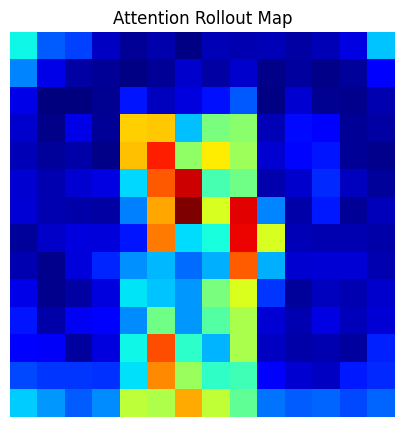

In [19]:
mask = cls_attention.reshape(grid_size, grid_size).detach().cpu().numpy()

# 0~1 정규화
mask = mask - mask.min()
mask = mask / (mask.max() + 1e-8)

# heatmap 시각화
plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap="jet")
plt.title("Attention Rollout Map")
plt.axis("off")
plt.show()


# 원본 이미지 복원(input_tensor가 normalize 되었기 때문에 다시 복원)

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
def denormalize_image(img_tensor, mean, std):
    """
    img_tensor: (3, H, W)
    """
    mean = torch.tensor(mean, device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor(std, device=img_tensor.device).view(3, 1, 1)
    img = img_tensor * std + mean
    img = img.clamp(0, 1)
    return img
img = denormalize_image(input_tensor[0], mean, std)
img = img.permute(1, 2, 0).detach().cpu().numpy()   # (H, W, 3)



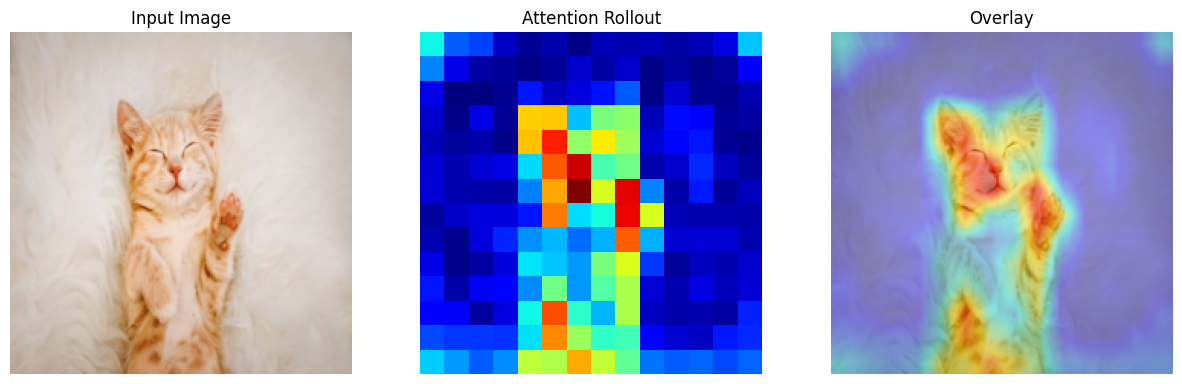

In [20]:
# 그림 시각화
H, W, _ = img.shape
mask_resized = cv2.resize(mask, (W, H))

heatmap = cv2.applyColorMap(np.uint8(255 * mask_resized), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

overlay = 0.6 * img + 0.4 * heatmap
overlay = np.clip(overlay, 0, 1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="jet")
plt.title("Attention Rollout")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()

Q8. 기존의 Attention Score 기반 explanation 말고 위와 같은 Attention rollout 방법을 사용하는 이유를 알려주세요.

답: 기존 Attention score 기반 explanation은 특정 레이어의 부분적인 참조 관계만 보여주므로, residual connetion과 다층 attention을 거친 실제 정보 전달 과정을 충분히 반영하지 못한다는 한계가 있다. Attention rollout은 각 레이어의 attention을 누적하여 입력 토큰이 최종 출력에 미친 전체 영향 경로를 추적하므로, 모델의 최종 판단 근거를 더 잘 설명할 수 있다.

(Optional) Q9. Attention Score를 기반으로 해석한, Score가 높은 word token 혹은 patch token으로 어떤 방법론을 만들 수 있을까요?(EX. ViT에서 Attention Score가 높은 patch token들을 따로 모아서 세밀한 부분을 구별하는 discriminative features로 사용 등)

답: 예를 들어 ViT에서는 attention score가 높은 patch token만 선택하여 고해상도 재분석이나 2차 분류를 수행함으로써 세밀한 구별에 필요한 discriminative feature로 사용할 수 있다. NLP에서는 attention이 높은 word token을 핵심 키워드, 근거 문장, 요약 후보 추출에 활용할 수 있다.